# Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mohankrishnathalla/mental-health-and-burnout-in-tech-workers-2026/mental_health_burnout_tech_2026.csv')
df.head()

,employee_id,age,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,...,autonomy_score,stress_score,burnout_score,phq9_score,phq9_category,gad7_score,gad7_category,burnout_level,seeks_mental_health_support,job_change_intention
0,1,33,Male,India,Software Engineer,Lead,11,6.4,Small (51-200),Healthcare Tech,...,6.1,10.0,10.0,19,Moderately Severe (15-19),12,Moderate (10-14),Severe,1,1
1,2,24,Non-binary,USA,Full Stack Developer,Manager,0,5.7,Startup (1-50),Fintech,...,5.4,9.3,7.0,8,Mild (5-9),6,Mild (5-9),High,1,1
2,3,36,Prefer not to say,USA,Software Engineer,Lead,14,5.6,Mid (201-1000),Fintech,...,4.1,8.9,8.5,8,Mild (5-9),9,Mild (5-9),Severe,0,1
3,4,38,Non-binary,USA,Software Engineer,Lead,14,1.2,Mid (201-1000),SaaS / Cloud,...,7.3,10.0,10.0,14,Moderate (10-14),11,Moderate (10-14),Severe,0,1
4,5,22,Non-binary,France,ML Engineer,Junior,0,3.0,Small (51-200),AI / ML Startup,...,4.4,7.7,5.4,8,Mild (5-9),0,Minimal (0-4),Moderate,1,0


# Exploratory Data Analysis (EDA)

In [3]:
print("\nDataset Information:")
df.info()

print("\nDataset Description (numerical columns):")
display(df.describe(include='number'))

print("\nDataset Description (categorical columns):")
display(df.describe(include='object'))


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   employee_id                  100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   country                      100000 non-null  object 
 4   job_role                     100000 non-null  object 
 5   seniority_level              100000 non-null  object 
 6   years_experience             100000 non-null  int64  
 7   years_at_company             100000 non-null  float64
 8   company_size                 100000 non-null  object 
 9   industry                     100000 non-null  object 
 10  work_mode                    100000 non-null  object 
 11  salary_usd                   100000 non-null  int64  
 12  work_hours_per_week          100000 n

,employee_id,age,years_experience,years_at_company,salary_usd,work_hours_per_week,meetings_per_day,team_size,sleep_hours_per_night,exercise_days_per_week,...,job_satisfaction_score,social_support_score,deadline_pressure_score,autonomy_score,stress_score,burnout_score,phq9_score,gad7_score,seeks_mental_health_support,job_change_intention
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,31.305670,9.343690,2.492581,83285.490230,47.104080,4.162244,18.009650,6.102392,2.968730,...,4.834823,5.383951,6.385095,5.836528,7.055399,5.401675,6.27194,5.118920,0.497890,0.320020
std,28867.657797,6.427924,6.401543,2.450426,39392.584827,5.246902,1.937849,12.607473,0.998808,1.772762,...,1.920796,1.832774,1.769242,1.836491,2.128530,2.668425,4.95427,4.007513,0.499998,0.466486
min,1.000000,22.000000,0.000000,0.100000,40000.000000,35.000000,0.000000,2.000000,3.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,26.000000,4.000000,0.700000,46018.250000,44.000000,2.800000,8.000000,5.400000,2.000000,...,3.500000,4.100000,5.200000,4.600000,5.500000,3.500000,2.00000,2.000000,0.000000,0.000000
50%,50000.500000,31.000000,9.000000,1.700000,76630.500000,47.000000,4.000000,16.000000,6.100000,3.000000,...,4.800000,5.400000,6.400000,5.800000,7.100000,5.400000,6.00000,5.000000,0.000000,0.000000
75%,75000.250000,36.000000,14.000000,3.500000,109113.000000,51.000000,5.400000,25.000000,6.800000,4.000000,...,6.200000,6.600000,7.600000,7.100000,8.900000,7.400000,10.00000,8.000000,1.000000,1.000000
max,100000.000000,55.000000,25.000000,15.000000,267961.000000,72.000000,12.000000,59.000000,10.000000,7.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,27.00000,21.000000,1.000000,1.000000



Dataset Description (categorical columns):


,gender,country,job_role,seniority_level,company_size,industry,work_mode,phq9_category,gad7_category,burnout_level
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,4,10,12,6,5,10,3,5,4,4
top,Male,USA,Software Engineer,Mid,Mid (201-1000),SaaS / Cloud,Hybrid,None (0-4),Minimal (0-4),Severe
freq,65243,31966,20080,28092,25062,19957,39856,40918,47532,28576


In [4]:
outlier_summary = {}

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary[col] = outlier_count

outlier_summary = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['outlier_count'])
outlier_summary.sort_values(by='outlier_count', ascending=False)

,outlier_count
uses_therapy,15185
years_at_company,4600
team_size,3437
meetings_per_day,653
sleep_hours_per_night,634
deadline_pressure_score,535
salary_usd,430
work_hours_per_week,353
vacation_days_taken,275
age,167


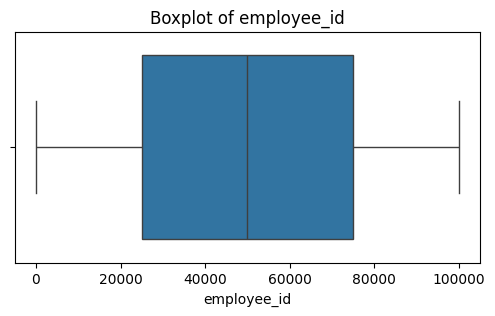

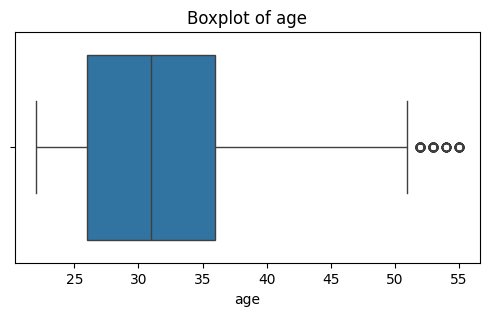

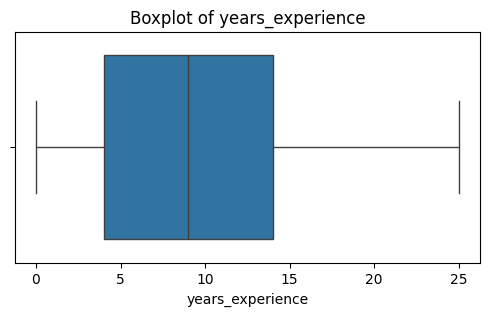

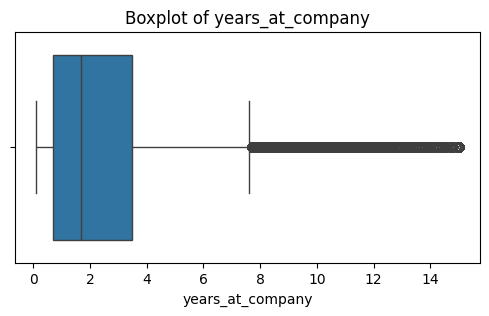

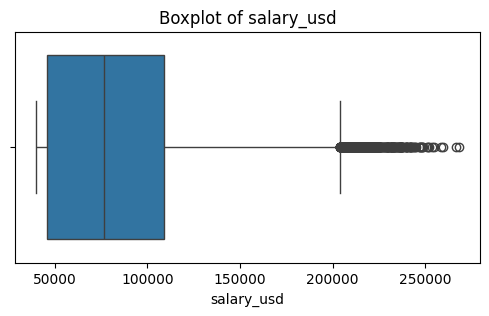

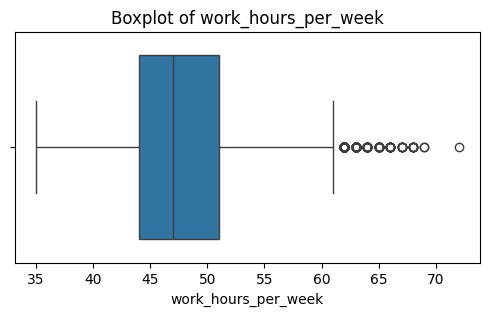

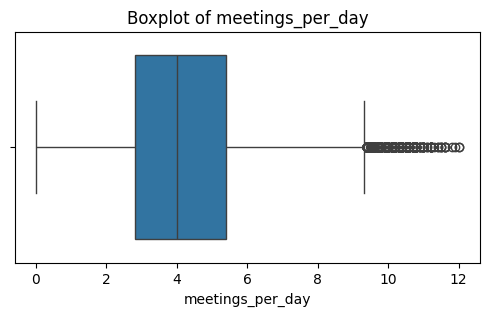

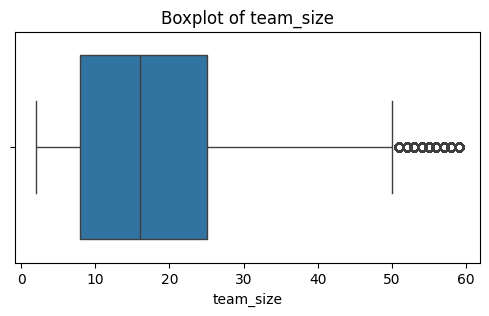

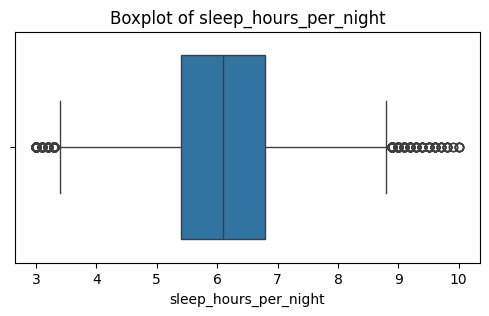

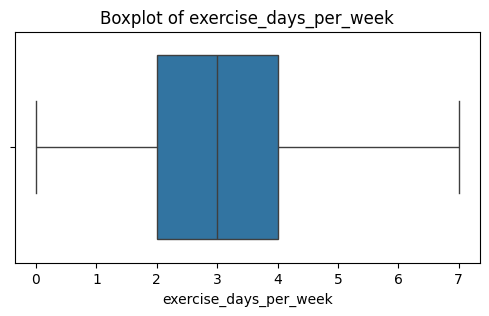

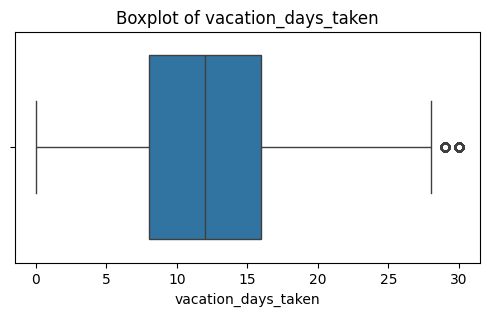

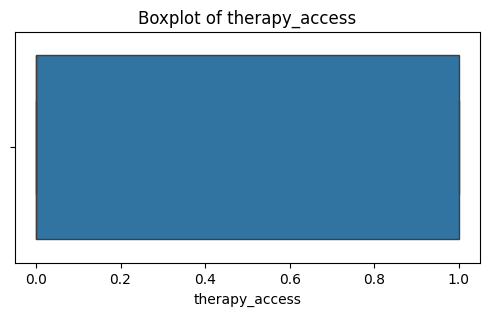

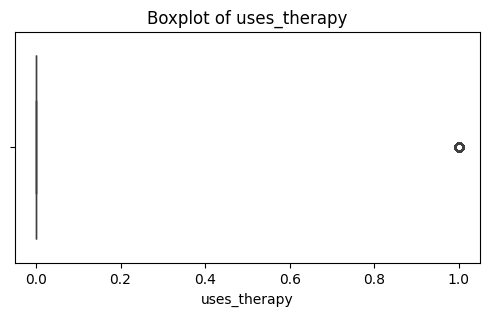

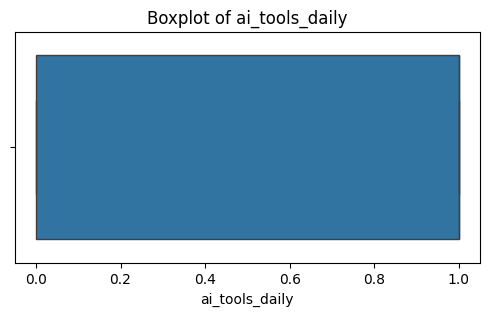

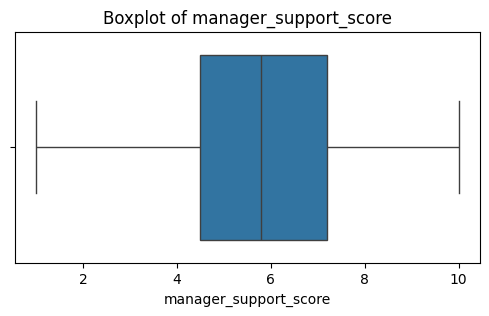

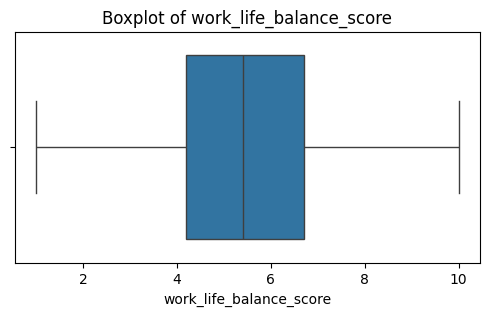

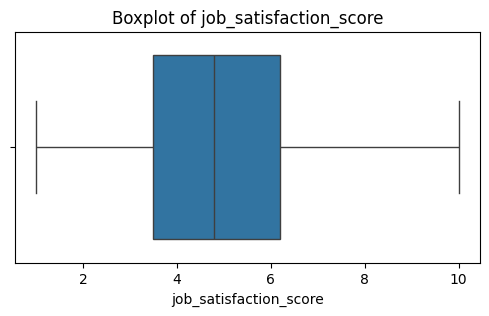

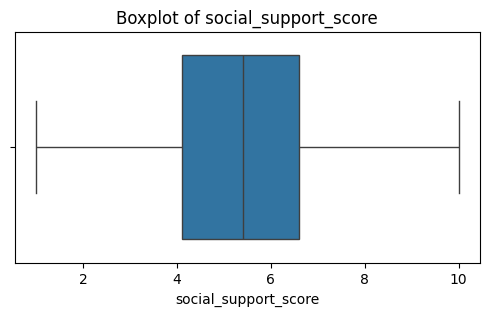

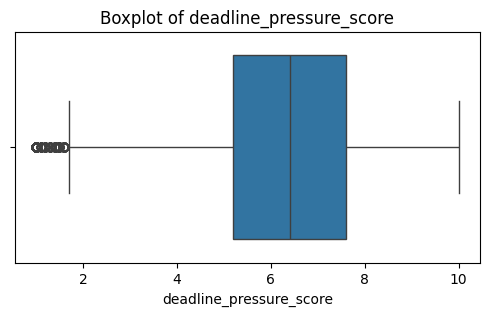

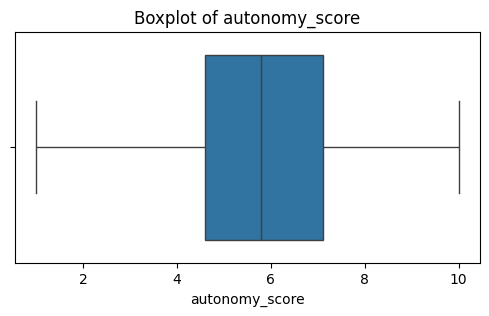

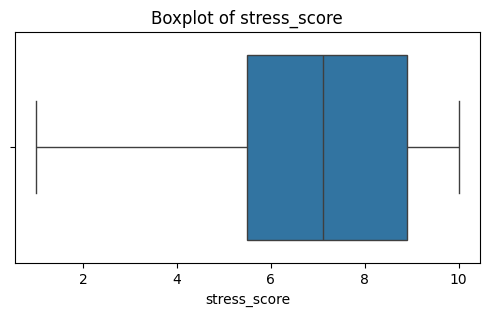

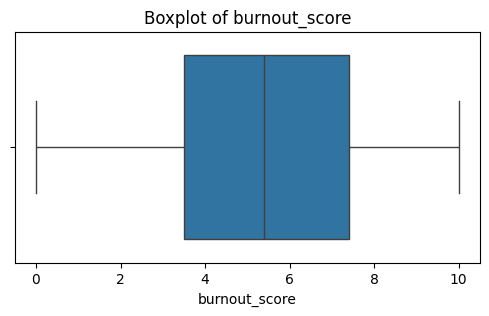

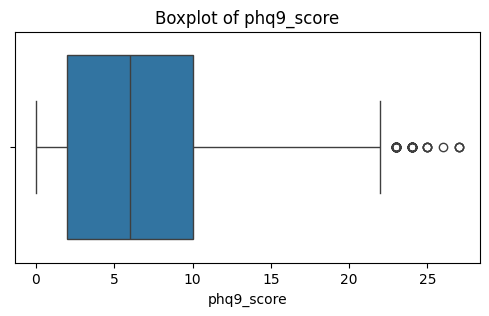

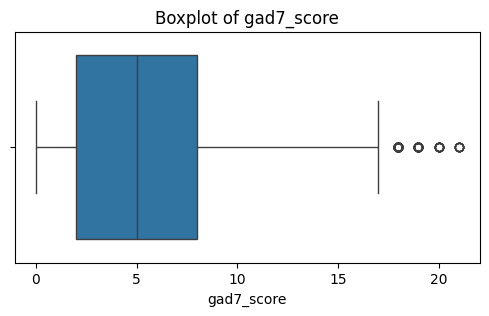

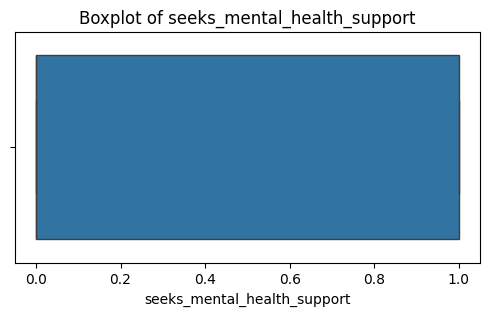

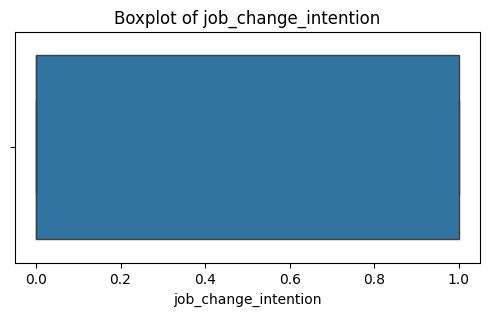

In [5]:
# Boxplot
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

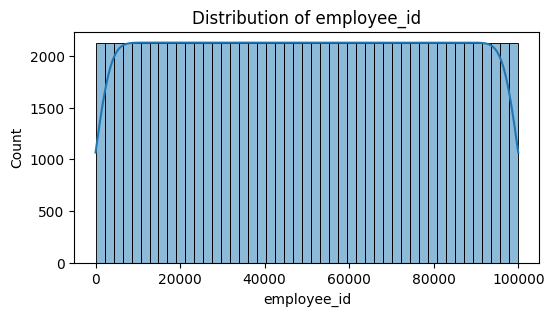

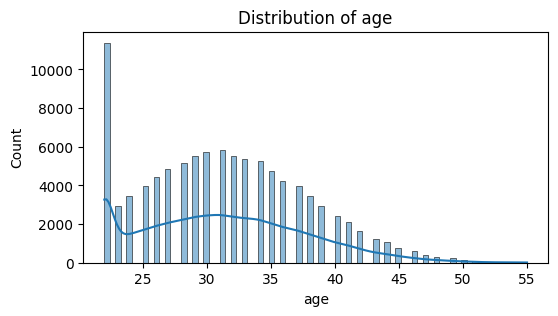

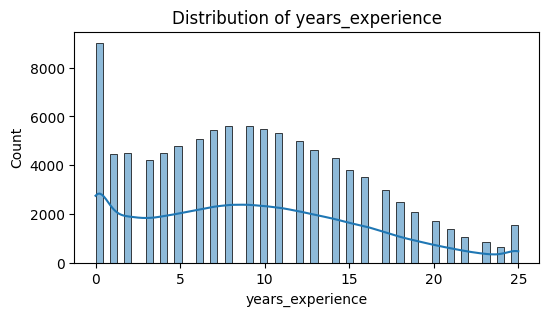

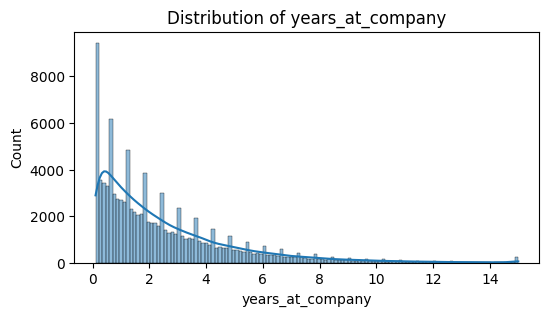

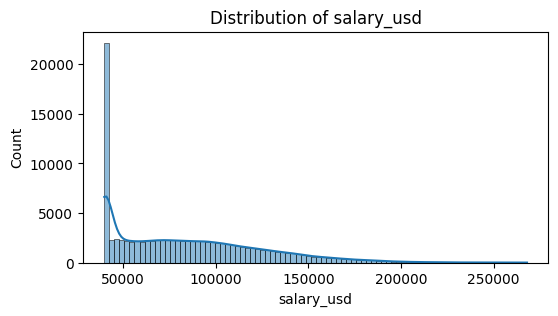

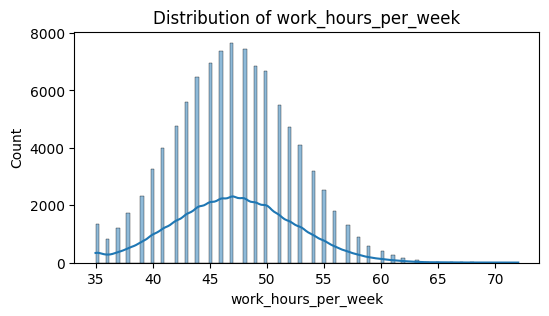

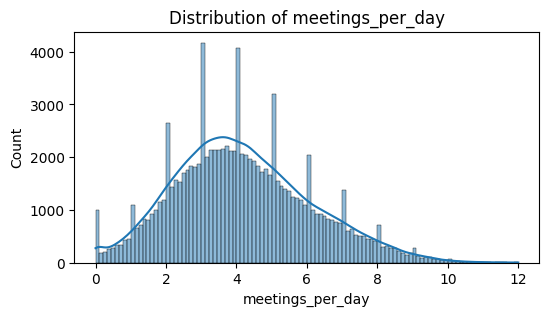

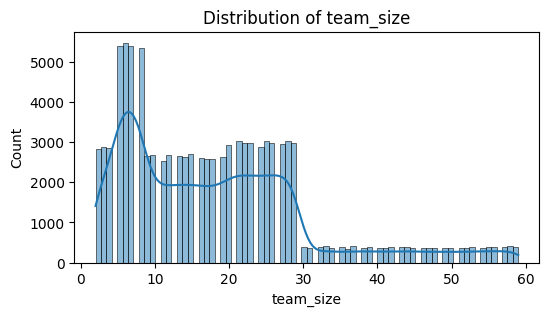

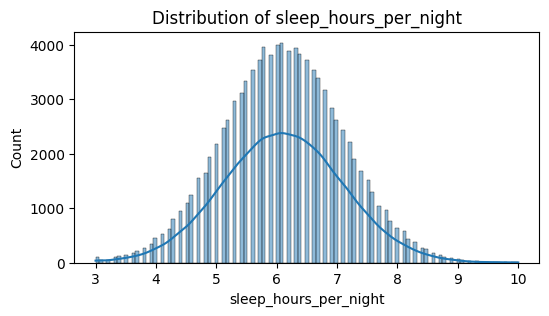

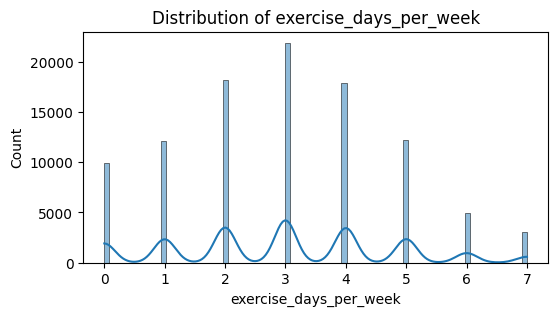

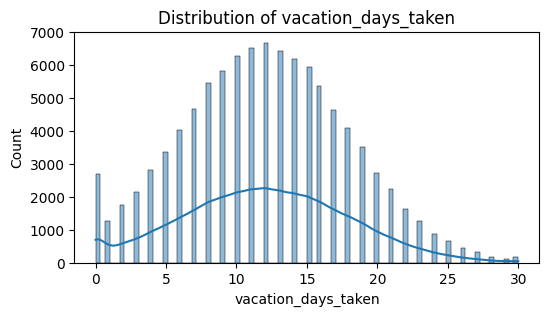

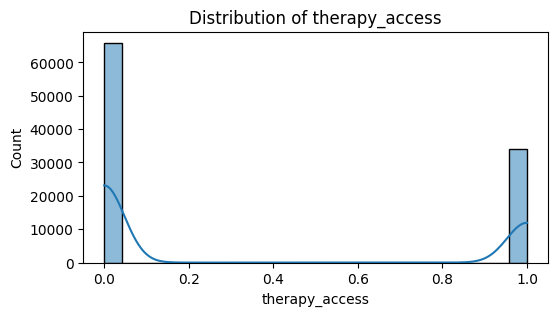

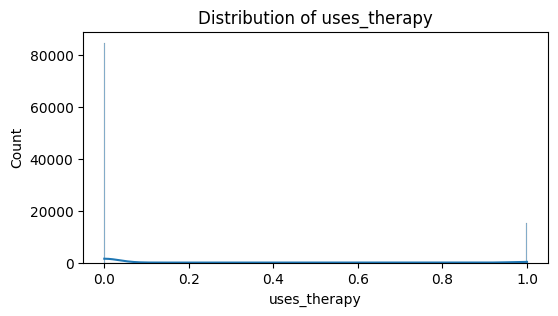

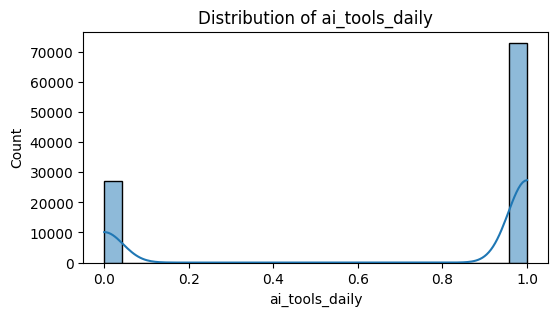

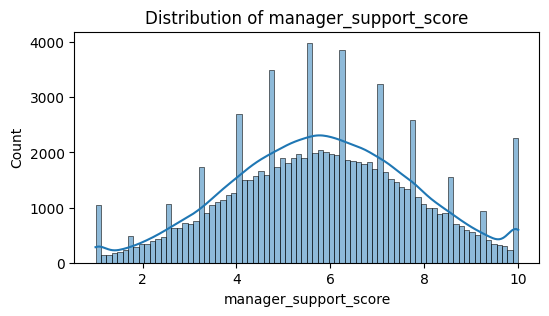

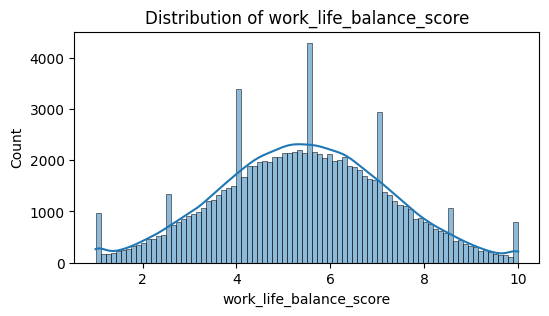

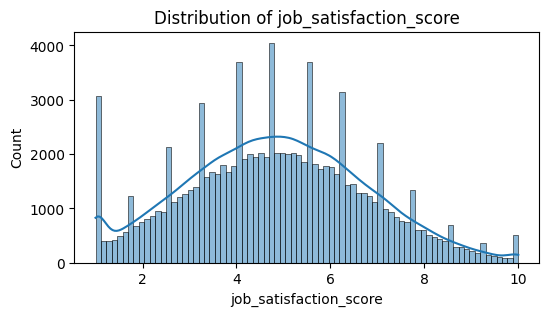

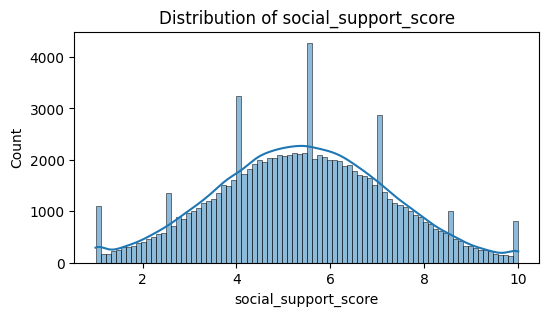

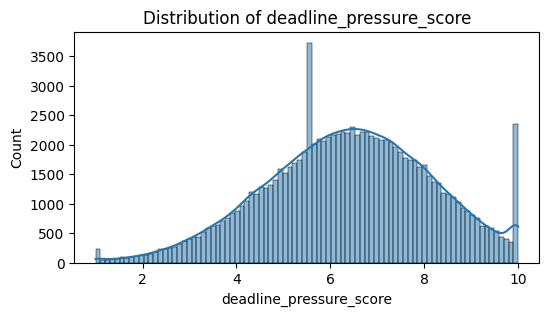

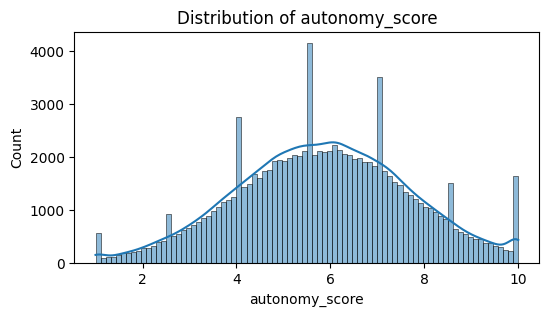

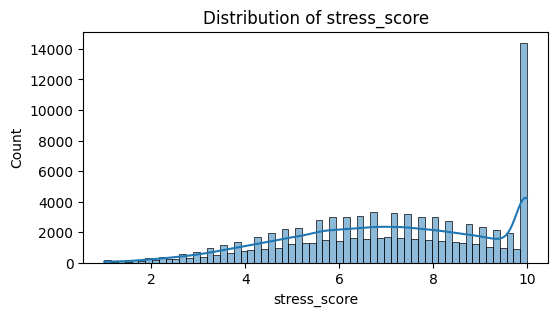

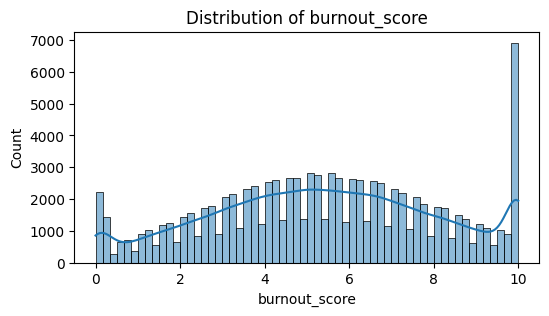

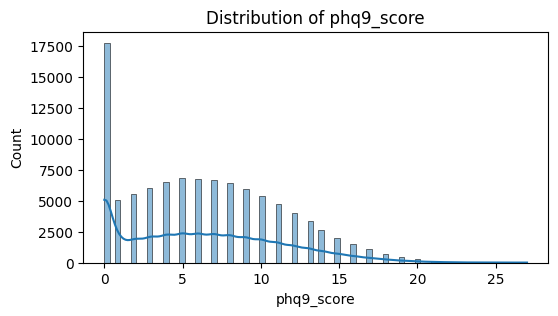

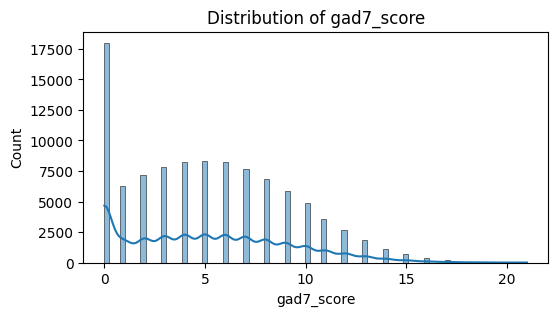

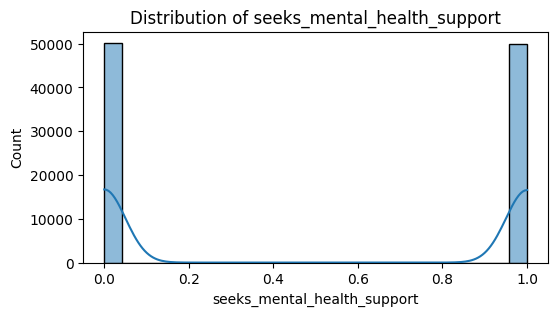

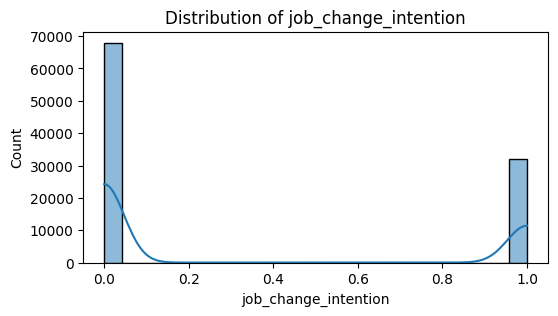

In [6]:
# Visual distribution
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Preprocessing

In [7]:
target_column = 'burnout_level'

extra_targets = [
    'seeks_mental_health_support',
    'job_change_intention',

    'burnout_score',
    'phq9_score',
    'phq9_category',
    'gad7_score',
    'gad7_category'
]

X = df.drop(columns=[target_column] + extra_targets)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() > 1 else None)

print(f"Original dataset shape: {df.shape}")
print(f"Training features (X_train) shape: {X_train.shape}")
print(f"Testing features (X_test) shape: {X_test.shape}")
print(f"Training target (y_train) shape: {y_train.shape}")
print(f"Testing target (y_test) shape: {y_test.shape}")

Original dataset shape: (100000, 36)
Training features (X_train) shape: (80000, 28)
Testing features (X_test) shape: (20000, 28)
Training target (y_train) shape: (80000,)
Testing target (y_test) shape: (20000,)


In [8]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'bool']).columns

print(f"Numerical columns identified: {list(numerical_cols)}")
print(f"Categorical columns identified: {list(categorical_cols)}")

Numerical columns identified: ['employee_id', 'age', 'years_experience', 'years_at_company', 'salary_usd', 'work_hours_per_week', 'meetings_per_day', 'team_size', 'sleep_hours_per_night', 'exercise_days_per_week', 'vacation_days_taken', 'therapy_access', 'uses_therapy', 'ai_tools_daily', 'manager_support_score', 'work_life_balance_score', 'job_satisfaction_score', 'social_support_score', 'deadline_pressure_score', 'autonomy_score', 'stress_score']
Categorical columns identified: ['gender', 'country', 'job_role', 'seniority_level', 'company_size', 'industry', 'work_mode']


In [9]:
def remove_outliers(X, y, numerical_cols):

    df_temp = X.copy()
    df_temp["target"] = y.values

    mask = pd.Series(True, index=df_temp.index)

    for col in numerical_cols:
        Q1 = df_temp[col].quantile(0.25)
        Q3 = df_temp[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        mask &= df_temp[col].between(lower, upper)

    df_temp = df_temp[mask]

    return df_temp.drop(columns=["target"]), df_temp["target"]

In [10]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

def build_preprocessor():
    return ColumnTransformer([
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

X_train_raw = X_train
y_train_raw = y_train

def get_preprocessed_data(X_tr, X_te):
    preprocessor = build_preprocessor()
    X_tr_p = preprocessor.fit_transform(X_tr)
    X_te_p = preprocessor.transform(X_te)
    return X_tr_p, X_te_p

X_train_raw_p, X_test_p = get_preprocessed_data(X_train_raw, X_test)

X_train_out, y_train_out = remove_outliers(X_train_raw, y_train_raw, numerical_cols)
X_train_out_p, X_test_out_p = get_preprocessed_data(X_train_out, X_test)

print("\nData cleaning applied successfully.")
print(f"Shape of cleaned training data (raw): {X_train_raw_p.shape}")
print(f"Shape of cleaned training data (outlier removed): {X_train_out_p.shape}")
print(f"Shape of cleaned testing data: {X_test_p.shape}")


Data cleaning applied successfully.
Shape of cleaned training data (raw): (80000, 71)
Shape of cleaned training data (outlier removed): (60737, 71)
Shape of cleaned testing data: (20000, 71)


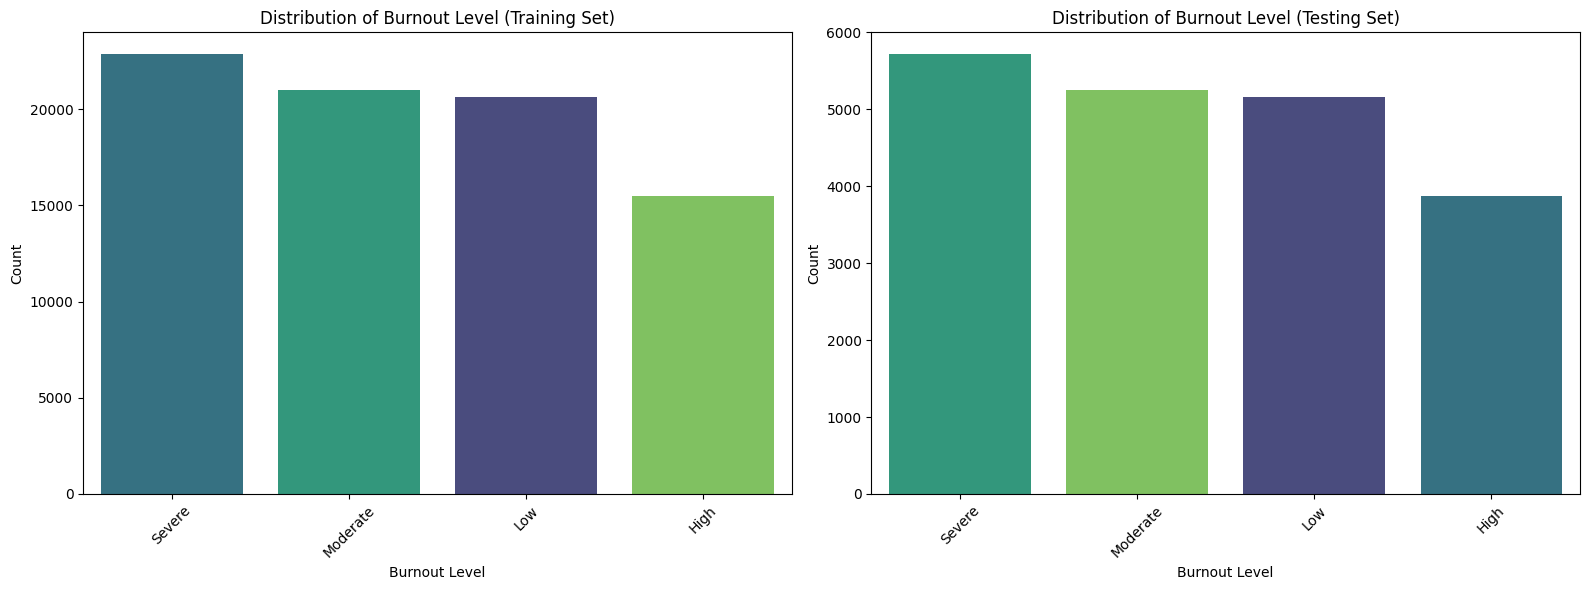

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x=y_train, order=y_train.value_counts().index, hue=y_train, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Distribution of Burnout Level (Training Set)')
axes[0].set_xlabel('Burnout Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x=y_test, order=y_test.value_counts().index, hue=y_test, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Distribution of Burnout Level (Testing Set)')
axes[1].set_xlabel('Burnout Level')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [12]:
print("\nOriginal Dataset (y) Distribution:")
display(y.value_counts(normalize=False).rename('Count').to_frame().join(
    y.value_counts(normalize=True).mul(100).rename('Percentage').to_frame().map(lambda x: f'{x:.2f}%')
))

print("\nTraining Set (y_train) Distribution:")
display(y_train.value_counts(normalize=False).rename('Count').to_frame().join(
    y_train.value_counts(normalize=True).mul(100).rename('Percentage').to_frame().map(lambda x: f'{x:.2f}%')
))

print("\nTesting Set (y_test) Distribution:")
display(y_test.value_counts(normalize=False).rename('Count').to_frame().join(
    y_test.value_counts(normalize=True).mul(100).rename('Percentage').to_frame().map(lambda x: f'{x:.2f}%')
))


Original Dataset (y) Distribution:


,Count,Percentage
burnout_level,,
Severe,28576,28.58%
Moderate,26255,26.25%
Low,25807,25.81%
High,19362,19.36%



Training Set (y_train) Distribution:


,Count,Percentage
burnout_level,,
Severe,22861,28.58%
Moderate,21004,26.25%
Low,20646,25.81%
High,15489,19.36%



Testing Set (y_test) Distribution:


,Count,Percentage
burnout_level,,
Severe,5715,28.57%
Moderate,5251,26.25%
Low,5161,25.80%
High,3873,19.36%


# Implementation

In [13]:
le = LabelEncoder()

y_train_enc     = le.fit_transform(y_train_raw)
y_train_out_enc = le.transform(y_train_out)
y_test_enc      = le.transform(y_test)

In [14]:
def evaluate_model(model_name, y_true, y_pred, class_names):

    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm        = confusion_matrix(y_true, y_pred)

    print(f"\n===== {model_name} =====")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "Scenario"  : model_name,
        "Accuracy"  : acc,
        "Precision" : precision,
        "Recall"    : recall,
        "F1"        : f1
    }

In [15]:
def run_svm_scenario(scenario_name, X_train_final, X_test_final, y_train_final, y_test_final):

    model = SVC(
        kernel='rbf',          
        C=1.0,               
        gamma='scale',       
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train_final, y_train_final)

    y_pred = model.predict(X_test_final)

    metrics = evaluate_model(scenario_name, y_test_final, y_pred, le.classes_)

    return model, metrics

## Scenario 1: Basic Preprocessing/Raw (No scaler or outlier removal)

In [16]:
def scenario_raw():
    return X_train_raw_p, X_test_p, y_train_enc, y_test_enc


===== Raw =====
Accuracy  : 0.3188
Precision : 0.3064
Recall    : 0.3188
F1-score  : 0.2252

Classification Report:

              precision    recall  f1-score   support

        High       0.26      0.00      0.00      3873
         Low       0.29      0.76      0.42      5161
    Moderate       0.27      0.00      0.00      5251
      Severe       0.38      0.43      0.40      5715

    accuracy                           0.32     20000
   macro avg       0.30      0.30      0.21     20000
weighted avg       0.31      0.32      0.23     20000



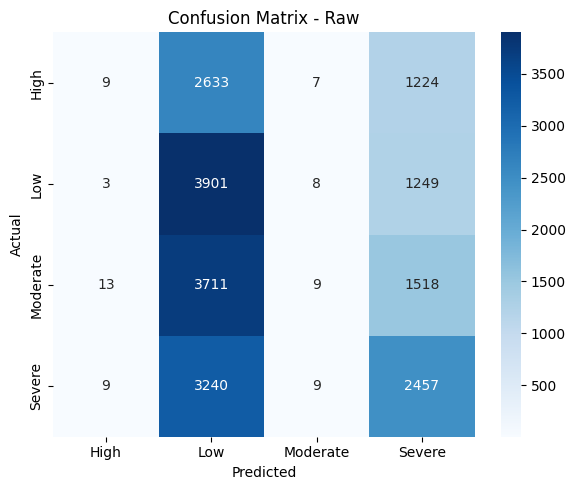

In [17]:
results = {}
models  = {}

X_train_final, X_test_final, y_train_final, y_test_final = scenario_raw()

from sklearn.utils import resample
X_train_final, y_train_final = resample(
    X_train_final, y_train_final,
    n_samples=15000,
    random_state=42,
    stratify=y_train_final
)

model, metrics = run_svm_scenario(
    "Raw",
    X_train_final, X_test_final,
    y_train_final, y_test_final
)

models["Raw"]  = model
results["Raw"] = metrics

## Scenario 2: Standard Scaler

In [18]:
from sklearn.preprocessing import StandardScaler

def scenario_scaler():
    X_tr, X_te = get_preprocessed_data(X_train_raw, X_test)

    scaler = StandardScaler(with_mean=False)
    X_train_final = scaler.fit_transform(X_tr)
    X_test_final  = scaler.transform(X_te)

    return X_train_final, X_test_final, y_train_enc, y_test_enc


===== StandardScaler =====
Accuracy  : 0.6973
Precision : 0.7092
Recall    : 0.6973
F1-score  : 0.7022

Classification Report:

              precision    recall  f1-score   support

        High       0.48      0.56      0.52      3873
         Low       0.83      0.79      0.81      5161
    Moderate       0.60      0.60      0.60      5251
      Severe       0.85      0.80      0.82      5715

    accuracy                           0.70     20000
   macro avg       0.69      0.69      0.69     20000
weighted avg       0.71      0.70      0.70     20000



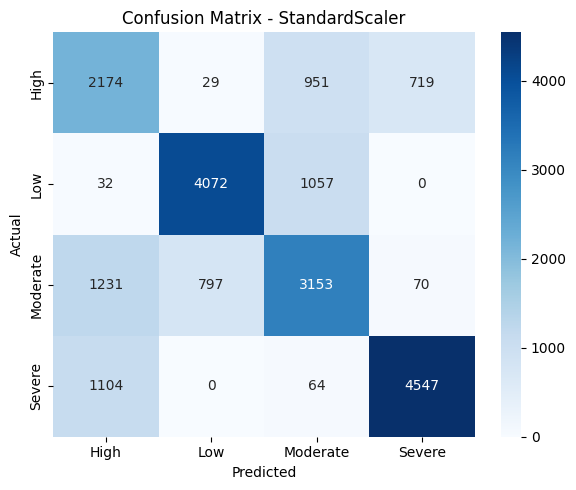

In [19]:
X_train_final, X_test_final, y_train_final, y_test_final = scenario_scaler()

X_train_final, y_train_final = resample(
    X_train_final, y_train_final,
    n_samples=15000,
    random_state=42,
    stratify=y_train_final
)

model, metrics = run_svm_scenario(
    "StandardScaler",
    X_train_final, X_test_final,
    y_train_final, y_test_final
)

models["StandardScaler"]  = model
results["StandardScaler"] = metrics

## Scenario 3: Outlier Removal

In [20]:
def scenario_outlier():
    return X_train_out_p, X_test_out_p, y_train_out_enc, y_test_enc


===== Outlier =====
Accuracy  : 0.3161
Precision : 0.2912
Recall    : 0.3161
F1-score  : 0.2268

Classification Report:

              precision    recall  f1-score   support

        High       0.18      0.01      0.02      3873
         Low       0.29      0.75      0.42      5161
    Moderate       0.28      0.00      0.00      5251
      Severe       0.38      0.42      0.40      5715

    accuracy                           0.32     20000
   macro avg       0.28      0.30      0.21     20000
weighted avg       0.29      0.32      0.23     20000



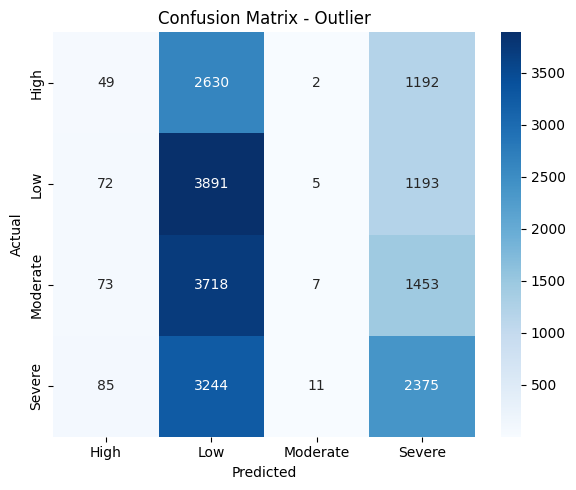

In [21]:
X_train_final, X_test_final, y_train_final, y_test_final = scenario_outlier()

X_train_final, y_train_final = resample(
    X_train_final, y_train_final,
    n_samples=15000,
    random_state=42,
    stratify=y_train_final
)

model, metrics = run_svm_scenario(
    "Outlier",
    X_train_final, X_test_final,
    y_train_final, y_test_final
)

models["Outlier"]  = model
results["Outlier"] = metrics

## Scenario 4: SMOTE

In [22]:
from imblearn.over_sampling import SMOTE

def scenario_smote():
    X_tr, X_te = get_preprocessed_data(X_train_raw, X_test)

    smote = SMOTE(random_state=42)
    X_train_final, y_train_final = smote.fit_resample(X_tr, y_train_enc)

    return X_train_final, X_te, y_train_final, y_test_enc


===== SMOTE =====
Accuracy  : 0.3186
Precision : 0.2960
Recall    : 0.3186
F1-score  : 0.2650

Classification Report:

              precision    recall  f1-score   support

        High       0.19      0.00      0.00      3873
         Low       0.29      0.63      0.40      5161
    Moderate       0.28      0.13      0.18      5251
      Severe       0.38      0.43      0.40      5715

    accuracy                           0.32     20000
   macro avg       0.29      0.30      0.25     20000
weighted avg       0.30      0.32      0.27     20000



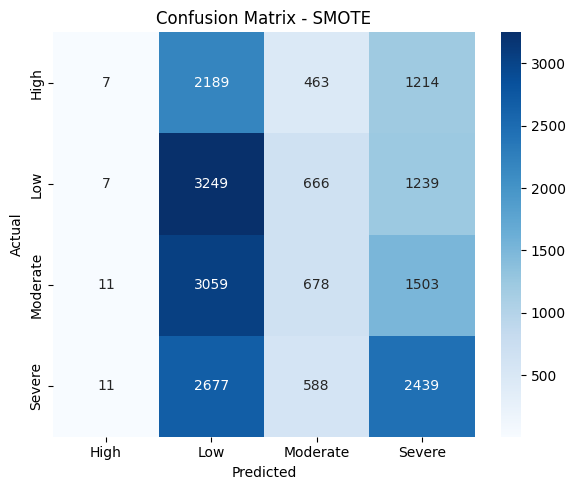

In [23]:
X_train_final, X_test_final, y_train_final, y_test_final = scenario_smote()

X_train_final, y_train_final = resample(
    X_train_final, y_train_final,
    n_samples=15000,
    random_state=42,
    stratify=y_train_final
)

model, metrics = run_svm_scenario(
    "SMOTE",
    X_train_final, X_test_final,
    y_train_final, y_test_final
)

models["SMOTE"]  = model
results["SMOTE"] = metrics

## Scenario 5: Mix all Scenarios

In [24]:
def scenario_mix():
    X_tr, X_te = get_preprocessed_data(X_train_raw, X_test)

    scaler = StandardScaler(with_mean=False)
    X_scaled    = scaler.fit_transform(X_tr)
    X_test_final = scaler.transform(X_te)

    df_scaled = pd.DataFrame(X_scaled)

    outlier_count = np.zeros(len(df_scaled))

    for col in df_scaled.columns:
        Q1 = df_scaled[col].quantile(0.25)
        Q3 = df_scaled[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outlier_count += ~df_scaled[col].between(lower, upper)

    mask = outlier_count <= 2

    X_filtered = df_scaled[mask].values
    y_filtered = y_train_enc[mask]

    if len(X_filtered) < 10:
        print("Warning: too few samples after filtering. Skipping outlier step.")
        X_filtered = X_scaled
        y_filtered = y_train_enc

    smote = SMOTE(random_state=42)
    X_train_final, y_train_final = smote.fit_resample(X_filtered, y_filtered)

    return X_train_final, X_test_final, y_train_final, y_test_enc


===== Mix =====
Accuracy  : 0.6247
Precision : 0.6317
Recall    : 0.6247
F1-score  : 0.6074

Classification Report:

              precision    recall  f1-score   support

        High       0.40      0.15      0.21      3873
         Low       0.76      0.80      0.78      5161
    Moderate       0.45      0.71      0.55      5251
      Severe       0.84      0.71      0.77      5715

    accuracy                           0.62     20000
   macro avg       0.61      0.59      0.58     20000
weighted avg       0.63      0.62      0.61     20000



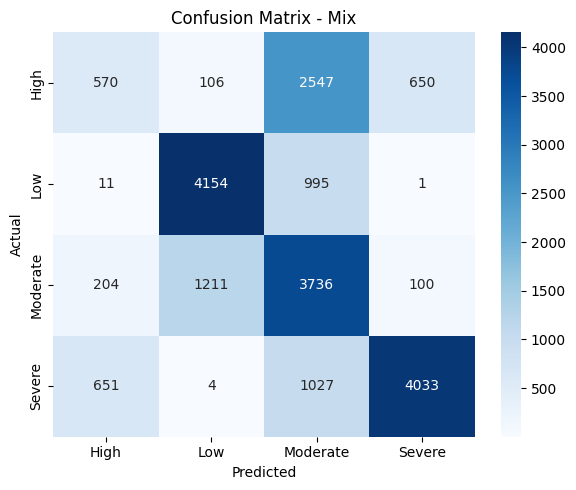

In [25]:
X_train_final, X_test_final, y_train_final, y_test_final = scenario_mix()

X_train_final, y_train_final = resample(
    X_train_final, y_train_final,
    n_samples=15000,
    random_state=42,
    stratify=y_train_final
)

model, metrics = run_svm_scenario(
    "Mix",
    X_train_final, X_test_final,
    y_train_final, y_test_final
)

models["Mix"]  = model
results["Mix"] = metrics

# Evaluation

In [26]:
results_df = pd.DataFrame(results).T
results_df.index.name = "Scenario"

results_df = results_df.sort_values("F1", ascending=False)

display(results_df)

,Scenario,Accuracy,Precision,Recall,F1
Scenario,,,,,
StandardScaler,StandardScaler,0.6973,0.709175,0.6973,0.702182
Mix,Mix,0.62465,0.631655,0.62465,0.607398
SMOTE,SMOTE,0.31865,0.295994,0.31865,0.26501
Outlier,Outlier,0.3161,0.291225,0.3161,0.22677
Raw,Raw,0.3188,0.306399,0.3188,0.225208
